In [4]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [43]:
# Load dataset
df = pd.read_csv("hospital_data.csv")

In [16]:
# Show first 5 rows
df.head()

,jurisdiction,weekEndingDate,totalConfC19NewAdm,totalConfFluNewAdm,totalConfRSVNewAdm,totalConfC19NewAdmPer100k,totalConfFluNewAdmPer100k,totalConfRSVNewAdmPer100k,totalConfC19NewAdmPer100kLevel,totalConfFluNewAdmPer100kLevel,totalConfRSVNewAdmPer100kLevel
0,CA,2026-04-18,139.0,186.0,168.0,0.36,0.48,0.43,Very Low,Very Low,Very Low
1,GA,2026-04-18,43.0,35.0,41.0,0.39,0.32,0.37,Very Low,Very Low,Very Low
2,NV,2026-04-18,6.0,20.0,6.0,0.19,0.63,0.19,Very Low,Very Low,Very Low
3,NY,2026-04-18,154.0,116.0,210.0,0.79,0.59,1.07,Very Low,Very Low,Low
4,OH,2026-04-18,14.0,27.0,63.0,0.12,0.23,0.53,Very Low,Very Low,Very Low


In [44]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   jurisdiction                    114 non-null    object 
 1   weekEndingDate                  114 non-null    object 
 2   totalConfC19NewAdm              108 non-null    float64
 3   totalConfFluNewAdm              108 non-null    float64
 4   totalConfRSVNewAdm              108 non-null    float64
 5   totalConfC19NewAdmPer100k       108 non-null    float64
 6   totalConfFluNewAdmPer100k       108 non-null    float64
 7   totalConfRSVNewAdmPer100k       108 non-null    float64
 8   totalConfC19NewAdmPer100kLevel  114 non-null    object 
 9   totalConfFluNewAdmPer100kLevel  114 non-null    object 
 10  totalConfRSVNewAdmPer100kLevel  114 non-null    object 
dtypes: float64(6), object(5)
memory usage: 9.9+ KB


In [45]:
# Column names
df.columns

Index(['jurisdiction', 'weekEndingDate', 'totalConfC19NewAdm',
       'totalConfFluNewAdm', 'totalConfRSVNewAdm', 'totalConfC19NewAdmPer100k',
       'totalConfFluNewAdmPer100k', 'totalConfRSVNewAdmPer100k',
       'totalConfC19NewAdmPer100kLevel', 'totalConfFluNewAdmPer100kLevel',
       'totalConfRSVNewAdmPer100kLevel'],
      dtype='object')

In [19]:
# Statistical summary
df.describe()

,totalConfC19NewAdm,totalConfFluNewAdm,totalConfRSVNewAdm,totalConfC19NewAdmPer100k,totalConfFluNewAdmPer100k,totalConfRSVNewAdmPer100k
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,59.518519,62.462963,83.796296,0.464074,0.498704,0.827963
std,216.871704,228.527445,304.239384,0.357209,0.403932,0.672415
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,7.000000,14.750000,0.265000,0.260000,0.410000
50%,16.500000,17.000000,25.500000,0.395000,0.410000,0.655000
75%,39.250000,35.500000,58.250000,0.557500,0.590000,1.085000
max,1629.000000,1711.000000,2318.000000,2.240000,2.560000,4.120000


In [47]:
# Remove duplicates
df = df.drop_duplicates()


In [48]:
# Check missing values
df.isnull().sum()

jurisdiction                      0
weekEndingDate                    0
totalConfC19NewAdm                6
totalConfFluNewAdm                6
totalConfRSVNewAdm                6
totalConfC19NewAdmPer100k         6
totalConfFluNewAdmPer100k         6
totalConfRSVNewAdmPer100k         6
totalConfC19NewAdmPer100kLevel    0
totalConfFluNewAdmPer100kLevel    0
totalConfRSVNewAdmPer100kLevel    0
dtype: int64

In [49]:
# Fill missing values (forward fill)
df = df.fillna(method='ffill')

C:\Users\Mohammad Aman\AppData\Local\Temp\ipykernel_23512\1263895453.py:2: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [27]:
# Convert date column if present
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

KPI Calculation

In [50]:
# # Total records
total_records = df.shape[0]

In [51]:
# Numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

In [52]:
# Averave Value 
avg_values = df[numeric_cols].mean()
print("Total_Records:", total_records)
print("\nAverage Values:\n", avg_values)

total_records = df.shape[0]

Total_Records: 114

Average Values:
 totalConfC19NewAdm           58.114035
totalConfFluNewAdm           61.500000
totalConfRSVNewAdm           81.298246
totalConfC19NewAdmPer100k     0.482719
totalConfFluNewAdmPer100k     0.509649
totalConfRSVNewAdmPer100k     0.841053
dtype: float64


                                                             BASIC VISUALIZATION (MATPLOTLIB)

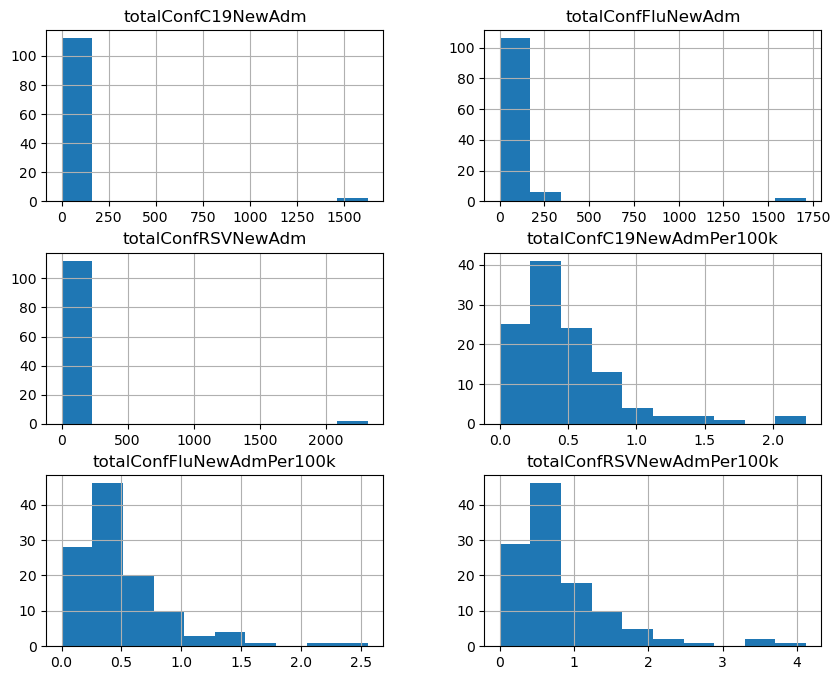

In [53]:
# Histogram
df.hist(figsize=(10,8))
plt.show()

                                                               CORRELATION HEATMAP (SEABORN)                                                        

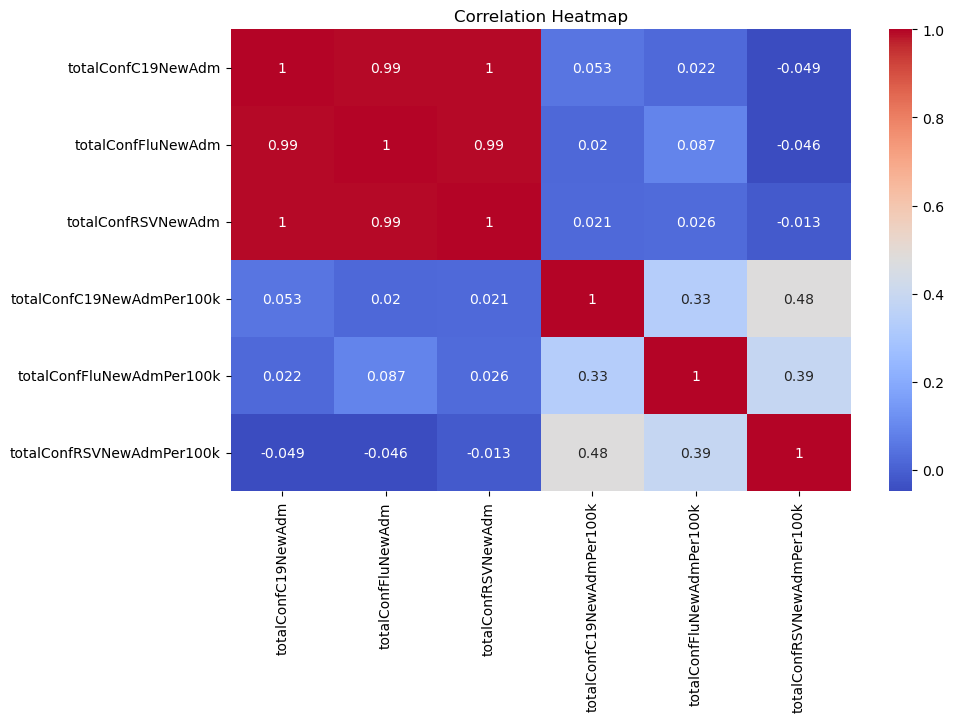

In [54]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

                                                               INTERACTIVE VISUALIZATION (PLOTLY)

In [55]:
# Select first numeric column for demo
col = numeric_cols[0]
fig = px.histogram(df, x = col, title=f"Distribution of {col}")
fig.show()